In [16]:
# Notebook 2.0: Exploratory Data Analysis & Target Label Engineering
# Objective: Define a robust target variable (y) to predict user churn. In a non-contractual fitness application like Endomondo, users don't explicitly cancel subscriptions; they simply become inactive.
# In this notebook, we will establish a data-driven inactivity threshold, evaluate the resulting target variable distribution, and implement advanced temporal caching to resolve historical data drift.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the aggregated summaries from Notebook 1.0
df = pd.read_csv('11endomondo_summaries.csv')
df['start_time'] = pd.to_datetime(df['start_time'])

print(f"Dataset successfully loaded: {df.shape[0]} total workouts across {df['userId'].nunique()} unique users.")

Dataset successfully loaded: 167783 total workouts across 1059 unique users.


In [18]:
# Phase 1: Naive Churn Labeling (Global 45-Day Rule)
# Hypothesis: We will assume that a user has "churned" if they have not logged a workout within the final 45 days of the entire dataset window.

In [19]:
# 1. Locate the absolute end of data collection
global_max_date = df['start_time'].max()
print(f"Global dataset end date: {global_max_date.date()}")

# 2. Identify the final workout logged by each individual user
user_last_workout_naive = df.groupby('userId')['start_time'].max().reset_index()
user_last_workout_naive.columns = ['userId', 'last_workout_time']

# 3. Compute inactivity duration relative to the global end date
user_last_workout_naive['days_inactive'] = (global_max_date - user_last_workout_naive['last_workout_time']).dt.days

# 4. Apply a fixed 45-day business rule
user_last_workout_naive['churned_naive'] = (user_last_workout_naive['days_inactive'] > 45).astype(int)

# 5. Display the distribution metrics
total_users = len(user_last_workout_naive)
counts = user_last_workout_naive['churned_naive'].value_counts()
pcts = user_last_workout_naive['churned_naive'].value_counts(normalize=True) * 100

print("\n--- NAIVE TARGET DISTRIBUTION RESULTS ---")
print(f"Retained Users (0): {counts.get(0, 0)} ({pcts.get(0, 0):.2f}%)")
print(f"Churned Users  (1): {counts.get(1, 0)} ({pcts.get(1, 0):.2f}%)")

Global dataset end date: 2019-04-07

--- NAIVE TARGET DISTRIBUTION RESULTS ---
Retained Users (0): 1 (0.09%)
Churned Users  (1): 1058 (99.91%)


In [20]:
# Observation: The naive approach yields an overwhelming 99.91% Churn Rate.
# The Problem (Surviving Bias & Historical Drift): If a machine learning model is fed this target variable, it will simply learn to predict 1 for every single user, resulting in 99.91% accuracy but zero actual predictive capability.
# Action: To visualize this phenomenon and pinpoint where the user base actually drops off, we will sample 500 random users and chart their active timeline lifespans.

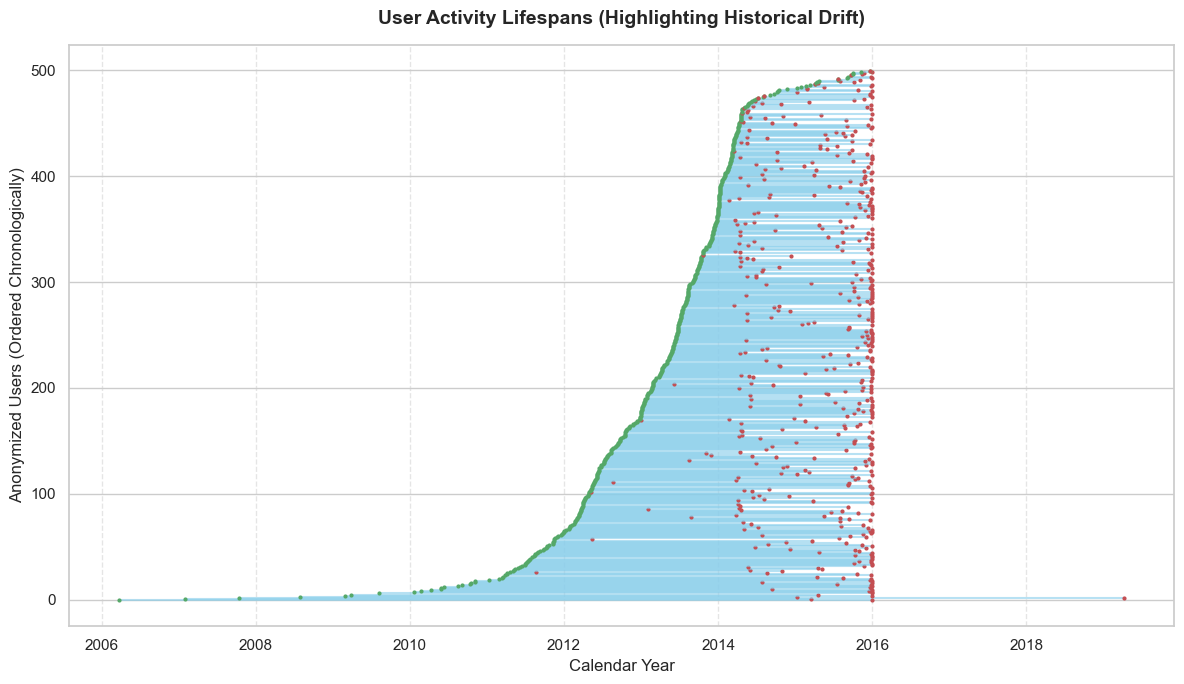

In [21]:
# 1. Aggregate entry and exit milestones for all users
user_lifespans = df.groupby('userId').agg(
    first_workout=('start_time', 'min'),
    last_workout=('start_time', 'max')
).reset_index()

# 2. Sample 500 users for visual clarity and sort by their adoption date
sample_users = user_lifespans.sample(min(500, len(user_lifespans)), random_state=42).sort_values('first_workout')

# 3. Construct the Horizontal Timeline Visualization
plt.figure(figsize=(12, 7))
for i, (idx, row) in enumerate(sample_users.iterrows()):
    plt.hlines(y=i, xmin=row['first_workout'], xmax=row['last_workout'], color='skyblue', linewidth=1.5, alpha=0.6)
    plt.plot(row['first_workout'], i, 'go', markersize=2) # Green dot = App Adoption
    plt.plot(row['last_workout'], i, 'ro', markersize=2)  # Red dot = Last Logged Workout

plt.title('User Activity Lifespans (Highlighting Historical Drift)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Calendar Year', fontsize=12)
plt.ylabel('Anonymized Users (Ordered Chronologically)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
# Phase 2: Correcting the Bias with a Simulated Snapshot Date
# Solution: To model churn realistically, we must simulate a live business environment. We will pick a historical window freeze date of December 31, 2015.
# If a user logged a workout within the 45 days prior to this snapshot, they are Retained (0).If they went completely silent for more than 45 days prior to this snapshot, they are Churned (1).

In [23]:
# 1. Establish the operational snapshot boundary
snapshot_cutoff = pd.to_datetime('2015-12-31')

# 2. Isolate historical workouts up to our snapshot date
df_snapshot = df[df['start_time'] <= snapshot_cutoff].copy()
print(f"Filtered dataset from {df.shape[0]} down to {df_snapshot.shape[0]} historical workouts.")

# 3. Recalculate user activity peaks relative strictly to our snapshot
user_profiles_2015 = df_snapshot.groupby('userId')['start_time'].max().reset_index()
user_profiles_2015.columns = ['userId', 'last_workout_before_cutoff']
user_profiles_2015['days_inactive'] = (snapshot_cutoff - user_profiles_2015['last_workout_before_cutoff']).dt.days

# 4. Generate the finalized, robust target variable
user_profiles_2015['churned'] = (user_profiles_2015['days_inactive'] > 45).astype(int)

# 5. Extract finalized class balance distribution
final_counts = user_profiles_2015['churned'].value_counts()
final_pcts = user_profiles_2015['churned'].value_counts(normalize=True) * 100

print("\n--- FINALIZED SANITIZED TARGET DISTRIBUTION ---")
print(f"Total Active Users in Frame: {len(user_profiles_2015)}")
print(f" -> Retained Users (Class 0): {final_counts.get(0, 0)} ({final_pcts.get(0, 0):.2f}%)")
print(f" -> Churned Users  (Class 1): {final_counts.get(1, 0)} ({final_pcts.get(1, 0):.2f}%)")


Filtered dataset from 167783 down to 167635 historical workouts.

--- FINALIZED SANITIZED TARGET DISTRIBUTION ---
Total Active Users in Frame: 1059
 -> Retained Users (Class 0): 406 (38.34%)
 -> Churned Users  (Class 1): 653 (61.66%)


In [25]:
# Phase 3: Missing Value Analysis & Feature Design
# Before we aggregate our workouts into a user-level feature matrix (X), we must evaluate the integrity of our columns. If a column like avg_hr (Heart Rate) or avg_speed contains too many missing values (NaN), it could destabilize our machine learning algorithms.

In [26]:
# Calculate the percentage of missing values (NaN) for every column
nan_analysis = df_snapshot.isnull().mean() * 100

print("--- MISSING DATA (NaN) PERCENTAGE PER COLUMN ---")
for col, missing_pct in nan_analysis.items():
    print(f"Column '{col}': {missing_pct:.2f}% missing values")

# Thought Process Decision Rule:
# Typically, columns with > 50% missing values are candidates for deletion. 
# For columns with moderate missing values (e.g., heart rate if users don't wear trackers),
# tree-based models like XGBoost/LightGBM can natively handle them without imputation!

--- MISSING DATA (NaN) PERCENTAGE PER COLUMN ---
Column 'userId': 0.00% missing values
Column 'sport': 0.00% missing values
Column 'avg_hr': 0.00% missing values
Column 'avg_speed': 81.13% missing values
Column 'start_time': 0.00% missing values
Column 'duration_min': 0.00% missing values
Column 'start_lat': 0.00% missing values
Column 'start_lon': 0.00% missing values


In [27]:
# Phase 4: Missing Value Filtering & User-Level Aggregation Logic
# Data Quality Decision: Based on our missing value analysis, the avg_speed column contains 81.13% missing values. Therefore, we will deliberately drop avg_speed from our pipeline.
# Aggregation Strategy:
# sport: Calculate Sport Diversity (the number of unique sports a user has tried).
# avg_hr: Compute the overall historical average heart rate to capture user fitness/intensity profiles.
# duration_min: Calculate both total time spent in the app and average workout length.
# start_lat & start_lon: Capture their geographic anchoring point (home base) by taking their first recorded location.
# churned: Take the first value as our definitive binary target label (y).

In [30]:
print("Dropping 'avg_speed'")
# 1. drop the column 
# errors='ignore', this cell can now be rerun
df_snapshot = df_snapshot.drop(columns=['avg_speed'], errors='ignore')

print("Mapping target churn labels back onto the workout sessions...")
# 2. Map the 0/1 labels calculated 
final_churn_map = user_profiles_2015.set_index('userId')['churned'].to_dict()
df_snapshot['churned'] = df_snapshot['userId'].map(final_churn_map)

print("Aggregating workout history into single-row user profiles")
# 3. Group by user and apply aggregations
user_feature_matrix = df_snapshot.groupby('userId').agg(
    # Target Variable
    churned=('churned', 'first'),
    
    # Engagement Frequency
    total_workouts=('start_time', 'count'),
    
    # Sport Variety (High diversity usually correlates with lower churn)
    sport_diversity=('sport', 'nunique'),
    
    # Performance Metrics (Only using Heart Rate now)
    overall_avg_hr=('avg_hr', 'mean'),
    
    # Temporal Profiles (Total commitment vs. average session length)
    total_active_minutes=('duration_min', 'sum'),
    avg_workout_duration=('duration_min', 'mean'),
    
    # Spatial/Geographic Anchoring (Capturing the first known coordinates as a proxy for region)
    home_lat=('start_lat', 'first'),
    home_lon=('start_lon', 'first')
).reset_index()

print(f"\nTransformation Complete!")
print(f"Shape of final Machine Learning Matrix: {user_feature_matrix.shape[0]} users x {user_feature_matrix.shape[1]} features.")

Dropping 'avg_speed'
Mapping target churn labels back onto the workout sessions...
Aggregating workout history into single-row user profiles

Transformation Complete!
Shape of final Machine Learning Matrix: 1059 users x 9 features.


In [32]:
user_feature_matrix.head()

,userId,churned,total_workouts,sport_diversity,overall_avg_hr,total_active_minutes,avg_workout_duration,home_lat,home_lon
0,69,0,78,3,138.664436,6428.550000,82.417308,55.240108,11.763726
1,2358,0,422,6,140.501976,21509.566667,50.970537,55.645030,12.635270
2,3808,1,170,3,138.150212,16823.666667,98.962745,41.880742,-87.620781
3,4101,1,63,3,134.294444,4658.066667,73.937566,55.480868,9.976205
4,4434,1,486,3,126.868926,37992.350000,78.173560,55.659014,12.589365


In [35]:
# Phase 5: Save as CSV 
output_user_matrix_file = 'endomondo_user_features.csv'

# Save to CSV
user_feature_matrix.to_csv(output_user_matrix_file, index=False)

print(f"Final user-level feature matrix saved as: {output_user_matrix_file}")
print(f"Total rows (Users to train on): {user_feature_matrix.shape[0]}")
print(f"Total columns (Predictors + Target): {user_feature_matrix.shape[1]}")

Final user-level feature matrix saved as: endomondo_user_features.csv
Total rows (Users to train on): 1059
Total columns (Predictors + Target): 9
